# Signal stability — performance signals (X) across the season

*Read-only informative artifact. Characterises how each candidate signal's
distribution moves across the season so a human can decide which signals are
poolable and which must be read within-block. No gate decisions, no
PROCEED/STOP verdict. The stability verdicts are **operational heuristics**
(fixed normalised-shift thresholds) offered as analytical guidance — not
statistical tests, not a gate.*

## Questions an analyst asks of the signals over time

- **Do signals drift across the season?** Does a signal's typical level or
  spread move from the early third to the late third?
- **Is a signal as trustworthy for a GW36 decision as for a GW10 one?** A
  signal whose distribution shifts late cannot be read off a season-pooled
  fingerprint at the end of the campaign.
- **Which signals can be pooled across the season, and which should be read
  within-block?** Every other foundation notebook pools the season; this one
  asks, per signal and position, whether that pooling is safe.

The structure `signal.ipynb` answered *what each signal looks like at rest*
(season-pooled). This notebook asks *how that fingerprint moves across the
season* — the same read-only class of artifact, one axis further.

## Setup

Load the mart, restrict to the **whole season** (GW 1 to the latest completed
GW) and the **participation** population (`minutes > 0`), carve the season into
three contiguous GW **blocks** (early / mid / late), and define the candidate
signal set.

This is a *descriptive characterisation* notebook, so it uses the full season —
no early-GW lower bound (that GW-6 cut in the older EDA-1 record was a
*predictive-evaluation* choice, not relevant here).

The population is everyone who **actually featured**: available players with
`minutes > 0`. This is a **participation** filter (the player appeared), **not
a performance gate**. `minutes` can be NULL for some rows; `minutes > 0`
naturally excludes those. The 60-minute performance-boundary question is
**deferred to the `population/` layer** and is deliberately not baked in here.

**Block definition.** The temporal unit is a *third of the season*. We split
`GW STUDY_GW_MIN .. STUDY_GW_MAX` into three near-equal contiguous blocks,
computed dynamically from the live GW range. The exact bounds are printed by
the setup cell below.

**Double-gameweek (DGW) honesty note.** Most candidate signals are **additive
per fixture** (`xg`, `xa`, `xgi`, `bps`, `bonus`, the ICT components), so a DGW
row roughly **doubles** them. DGW rounds cluster **late** in the season, so a
signal can look like it "drifts up" late purely because more rows in the late
block carry two fixtures. These block distributions **pool SGW and DGW rows**
(no normalisation, no exclusion); per-fixture treatment is **deferred to the
`fixture/` layer**. Read late-block shifts with that confound in mind.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.kernels.descriptive.block_distributions import (
    compute_signal_block_distributions,
)
from research.kernels.diagnostic.stability import (
    assess_distribution_stability,
    resolve_pooling_strategy,
)
from domain.fpl_signals import COMPOSITE_SIGNALS

try:
    _result = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _result = load_mart()

# Descriptive characterisation uses the WHOLE season: GW 1 to the latest
# completed GW. No early-GW lower bound (that GW-6 cut in the older EDA-1
# record was a predictive-evaluation choice, not relevant here).
STUDY_GW_MIN = 1
STUDY_GW_MAX = _result.data_cutoff_gw

# Analytical population: PARTICIPATION filter, not a performance gate.
# Available players who actually featured -> minutes > 0. `minutes` can be NULL
# for some rows; minutes > 0 naturally excludes NULLs (NULL comparisons are
# False). The 60-minute performance boundary is NOT imposed here -- that
# question is deferred to the population/ layer.
mart = _result.mart
df = mart[mart["gw"].between(STUDY_GW_MIN, STUDY_GW_MAX)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()

POSITIONS = ["GK", "DEF", "MID", "FWD"]

# Temporal unit: split the WHOLE completed season into three contiguous,
# (near-)equal GW blocks -- early / mid / late -- computed dynamically from the
# GW range so this notebook adapts to whatever the season's data_cutoff_gw is.
def _make_thirds(gw_min, gw_max):
    span = gw_max - gw_min + 1
    cut1 = gw_min + span // 3            # end of "early" (inclusive)
    cut2 = gw_min + (2 * span) // 3      # end of "mid"   (inclusive)
    return {
        "early": (gw_min, cut1),
        "mid":   (cut1 + 1, cut2),
        "late":  (cut2 + 1, gw_max),
    }

GW_BLOCKS = _make_thirds(STUDY_GW_MIN, STUDY_GW_MAX)
BLOCK_ORDER = ["early", "mid", "late"]

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.3f}".format)

print(f"Study range: GW {STUDY_GW_MIN} - GW {STUDY_GW_MAX} (whole season, from mart data_cutoff_gw)")
print(f"Population: minutes > 0 (participation, not a performance gate), n = {len(df):,} player-gameweeks")
for pos in POSITIONS:
    print(f"  {pos}: {len(df[df.position == pos]):>6,}")
print("\nGW blocks (thirds of the completed season, inclusive bounds):")
for name in BLOCK_ORDER:
    lo, hi = GW_BLOCKS[name]
    print(f"  {name:<6} GW {lo:>2} - {hi:<2}")

Study range: GW 1 - GW 38 (whole season, from mart data_cutoff_gw)
Population: minutes > 0 (participation, not a performance gate), n = 11,361 player-gameweeks
  GK:    757
  DEF:  3,904
  MID:  5,288
  FWD:  1,412

GW blocks (thirds of the completed season, inclusive bounds):
  early  GW  1 - 13
  mid    GW 14 - 26
  late   GW 27 - 38


In [2]:
# Candidate universe: the *alive* continuous / process signals whose season
# drift is a meaningful question (see TEMPORAL_DESIGN.md §5). Excludes near-
# degenerate negative events (own_goals, penalties_missed) and discrete
# outcome counts (goals/assists/cards/...) -- those are target components,
# not continuous signals.
_CANDIDATES = [
    "xg", "xa", "xgi", "xgc",
    "ict_index", "influence", "creativity", "threat",
    "bps", "bonus",
    "tackles", "clearances_blocks_interceptions", "recoveries", "defensive_contribution",
]

# Composite-narrowing (domain/fpl_signals.py): a composite parent and its
# components carry the same information, so for a stability read we keep the
# PARENT and drop the components -- xgi over xg/xa, ict_index over influence/
# creativity/threat, defensive_contribution over tackles/CBI/recoveries.
# Narrowed programmatically from COMPOSITE_SIGNALS (single source of truth).
_COMPONENTS = {c for comps in COMPOSITE_SIGNALS.values() for c in comps}
SIGNALS = [s for s in _CANDIDATES if s in df.columns and s not in _COMPONENTS]

print("Dropped (component of a composite parent):",
      sorted(_COMPONENTS & set(_CANDIDATES)))
print("Candidate signals (composite parents + standalones):", SIGNALS)

Dropped (component of a composite parent): ['clearances_blocks_interceptions', 'creativity', 'influence', 'recoveries', 'tackles', 'threat', 'xa', 'xg']
Candidate signals (composite parents + standalones): ['xgi', 'xgc', 'ict_index', 'bps', 'bonus', 'defensive_contribution']


## (a) Per-signal, per-block distribution by position

**What we measure** — for every (signal, position) pair, the median, IQR, and
upper-tail percentiles (p90/p99) of the signal in each season third, via
`compute_signal_block_distributions` over the candidate signal list. One row per (signal, position, block); `n` per cell
is shown so thin blocks (degenerate signal/position combinations, e.g. a
keeper's `xg`) are visible as NaN distribution stats.

*Stat glossary for this table:* **mean** — arithmetic average, pulled up by rare hauls; **median** — middle value, the robust "typical" return; **std** — typical distance from the mean in points, sensitive to outliers; **IQR (p75−p25)** — spread of the middle 50%, robust to skew; **p90/p99** — score exceeded by only 10%/1% of appearances (practical ceiling); **skew** — positive = long right tail of rare high scores.

**What it means** — this is each signal's per-position fingerprint, read three
times across the season. A median that climbs late, or an IQR that swells,
tells the analyst the signal is *not stationary* there — so a model that reads
that signal off a season-pooled level will mis-rate late-season players.

**What it doesn't mean** — these are **block-pooled** distributions across
players, not a within-player signal trajectory (deferred). Block boundaries are
arbitrary thirds. Additive signals inherit the **DGW confound**: DGW rounds
cluster late, so a late-block rise in `xg`/`bps`/etc. can be fixture-doubling
rather than a genuine distributional shift. Drift here is *spread/level* over
time, not predictive value for `total_points` (out of scope for this layer).

**Guiding question** — *Do signals drift across the season, and is a signal as
trustworthy late as it is early?*

In [3]:
# Per-(signal, position, block) median/IQR. NaN distribution stats appear where
# a block has n < 10 (e.g. structurally degenerate signal/position pairs).
sig_blocks = compute_signal_block_distributions(
    df, SIGNALS, POSITIONS, gw_column="gw", gw_blocks=GW_BLOCKS,
)
sig_blocks["block"] = pd.Categorical(sig_blocks["block"], categories=BLOCK_ORDER, ordered=True)
sig_blocks["position"] = pd.Categorical(sig_blocks["position"], categories=POSITIONS, ordered=True)
sig_blocks["signal"] = pd.Categorical(sig_blocks["signal"], categories=SIGNALS, ordered=True)
sig_blocks = sig_blocks.sort_values(["signal", "position", "block"]).reset_index(drop=True)
display(sig_blocks[["signal", "position", "block", "min_gw", "max_gw", "n", "median", "iqr", "p90", "p99"]])

,signal,position,block,min_gw,max_gw,n,median,iqr,p90,p99
0,xgi,GK,early,1,13,262,0.000,0.000,0.010,0.030
1,xgi,GK,mid,14,26,263,0.000,0.000,0.010,0.010
2,xgi,GK,late,27,38,232,0.000,0.000,0.009,0.099
3,xgi,DEF,early,1,13,1345,0.030,0.100,0.250,0.711
4,xgi,DEF,mid,14,26,1374,0.030,0.110,0.270,0.690
...,...,...,...,...,...,...,...,...,...,...
67,defensive_contribution,MID,mid,14,26,1772,5.000,7.000,12.000,19.000
68,defensive_contribution,MID,late,27,38,1593,5.000,7.000,12.000,19.000
69,defensive_contribution,FWD,early,1,13,447,2.000,3.000,6.000,10.540
70,defensive_contribution,FWD,mid,14,26,491,2.000,3.000,6.000,11.000


In [4]:
# A compact median-by-block pivot makes drift legible across all signals at
# once: read each (signal x position) row left-to-right (early -> mid -> late).
median_pivot = sig_blocks.pivot_table(
    index=["signal", "position"], columns="block", values="median", observed=True,
)[BLOCK_ORDER]
display(median_pivot.round(3))

block                            early    mid   late
signal                 position                     
xgi                    GK        0.000  0.000  0.000
                       DEF       0.030  0.030  0.030
                       MID       0.080  0.095  0.100
                       FWD       0.120  0.130  0.165
xgc                    GK        1.190  1.340  1.345
                       DEF       0.900  1.050  1.100
                       MID       0.660  0.795  0.890
                       FWD       0.650  0.680  0.740
ict_index              GK        2.100  2.000  2.200
                       DEF       2.400  2.600  2.400
                       MID       2.500  2.800  2.700
                       FWD       2.100  2.300  2.700
bps                    GK       12.000 12.000 13.000
                       DEF       8.000  8.000  9.000
                       MID       9.000 10.000 10.000
                       FWD       4.000  4.000  6.000
bonus                  GK        0.000  0.000  0.000
                       DEF       0.000  0.000  0.000
                       MID       0.000  0.000  0.000
                       FWD       0.000  0.000  0.000
defensive_contribution GK        0.000  0.000  0.000
                       DEF       6.000  6.000  6.000
                       MID       5.000  5.000  5.000
                       FWD       2.000  2.000  2.000

**Tail-aware view.** The stability verdict in (b) is a heuristic on the
*median*, so by construction it is blind to tail drift. This grid pairs each
(signal × position)'s **IQR band** with its **upper tail (p90/p99)** across the
three blocks, so spread or ceiling movement is visible even where the median is
flat. Rows are signals (each on its **own y-scale** — `xgi`≈0.1 and `bps`≈10 do
not share an axis); columns are positions. Degenerate cells (`xgi`/`defensive_contribution` at GK, `bonus` everywhere) show as flat lines —
read against the `n` column in the table above, not as real drift.

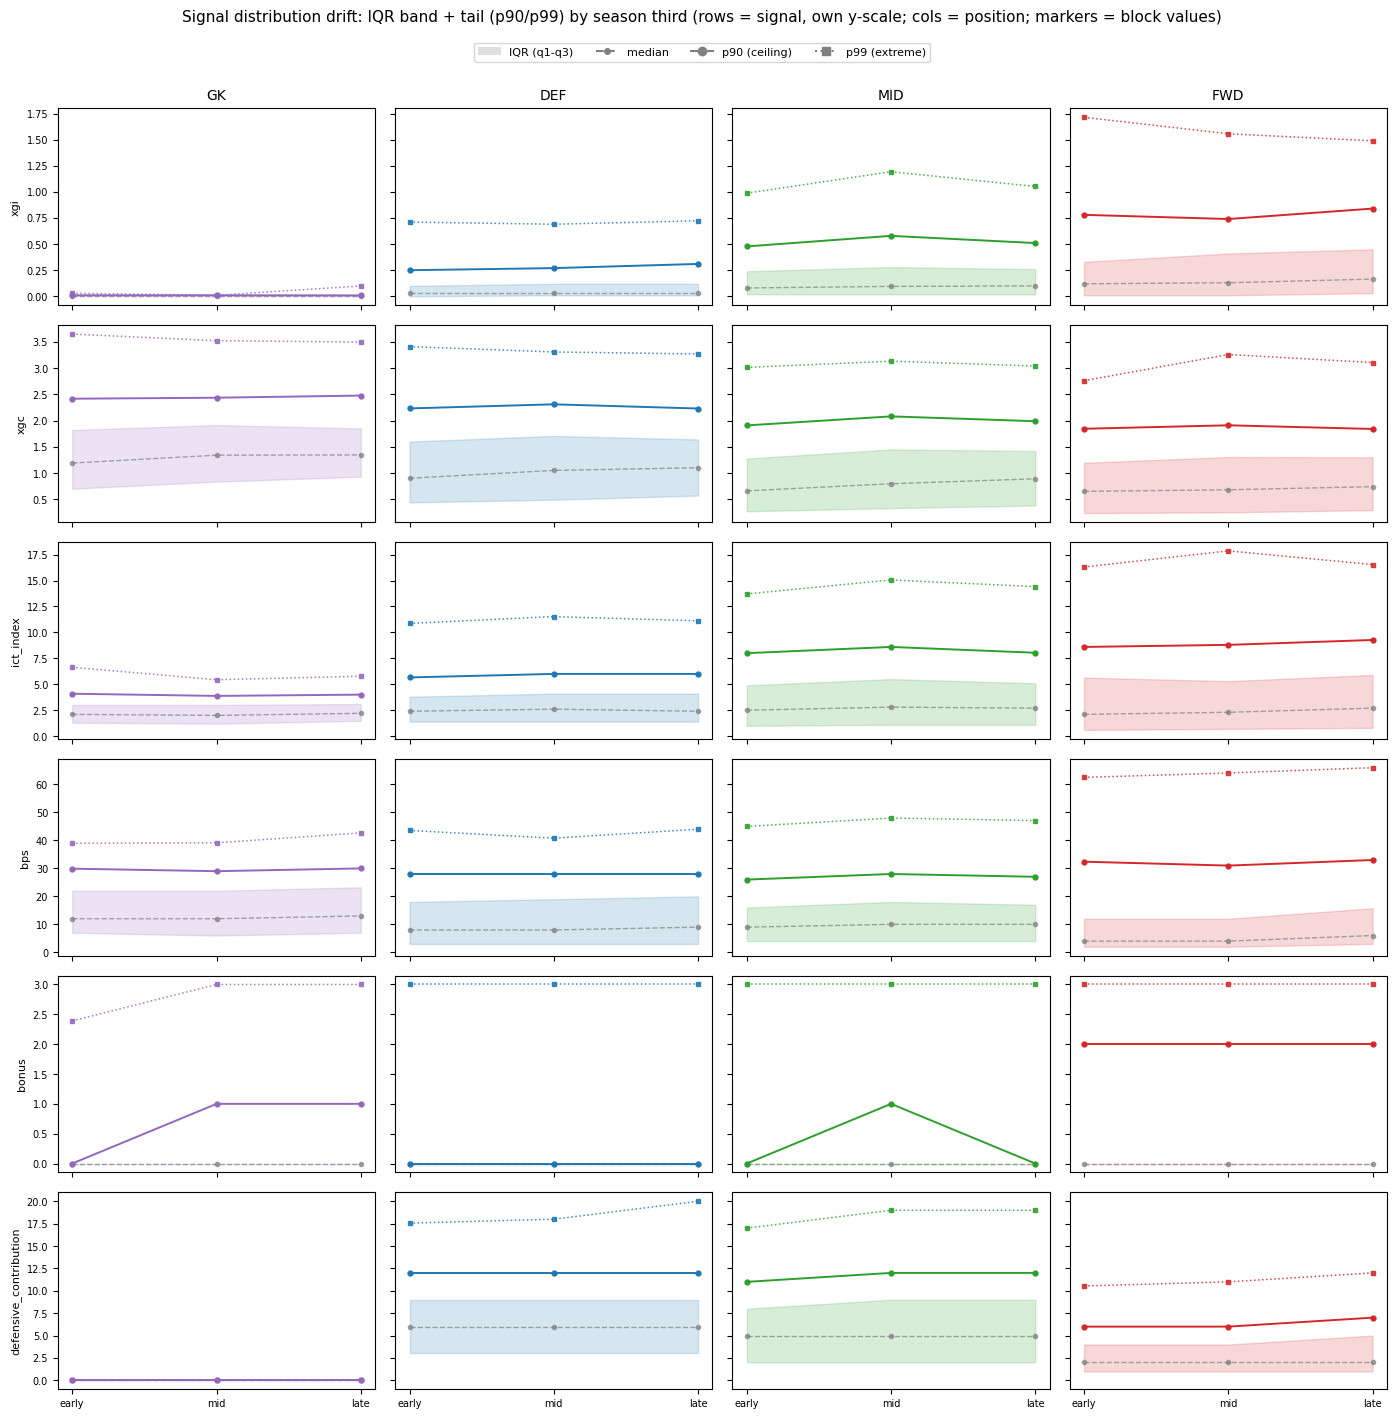

In [5]:
# IQR band + tail (p90/p99) per (signal x position) across blocks. Parallels the
# target_stability plot, extended to multiple signals: one row per signal on its
# own y-scale (sharey='row'), one column per position. Median demoted to a faint
# grey reference. Shows whether a signal's spread/ceiling moves even when the
# median-shift verdict reads 'stable'.
colours = {"GK": "#9467bd", "DEF": "#1f77b4", "MID": "#2ca02c", "FWD": "#d62728"}
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

x = np.arange(len(BLOCK_ORDER))
nrows = len(SIGNALS)
fig, axes = plt.subplots(nrows, len(POSITIONS), figsize=(14, 2.3 * nrows),
                         sharey="row", sharex=True)
for r, sig in enumerate(SIGNALS):
    for c, pos in enumerate(POSITIONS):
        ax = axes[r, c]
        sub = (sig_blocks[(sig_blocks["signal"] == sig) & (sig_blocks["position"] == pos)]
               .set_index("block").reindex(BLOCK_ORDER))
        q1 = sub["q1"].to_numpy(dtype=float)
        q3 = sub["q3"].to_numpy(dtype=float)
        med = sub["median"].to_numpy(dtype=float)
        p90 = sub["p90"].to_numpy(dtype=float)
        p99 = sub["p99"].to_numpy(dtype=float)
        col = colours[pos]
        ax.fill_between(x, q1, q3, color=col, alpha=0.18)
        ax.plot(x, med, "--o", color="grey", lw=1, ms=3, alpha=0.7)
        ax.plot(x, p90, "-o", color=col, lw=1.4, ms=3.5)
        ax.plot(x, p99, ":s", color=col, lw=1.1, ms=3.5, alpha=0.85)
        if r == 0:
            ax.set_title(pos, fontsize=10)
        if c == 0:
            ax.set_ylabel(sig, fontsize=8)
        ax.set_xticks(x)
        ax.set_xticklabels(BLOCK_ORDER if r == nrows - 1 else [], fontsize=7)
        ax.tick_params(axis="y", labelsize=7)
legend_elems = [
    Patch(facecolor="grey", alpha=0.25, label="IQR (q1-q3)"),
    Line2D([0], [0], color="grey", ls="--", marker="o", ms=4, label="median"),
    Line2D([0], [0], color="grey", marker="o", label="p90 (ceiling)"),
    Line2D([0], [0], color="grey", ls=":", marker="s", label="p99 (extreme)"),
]
fig.legend(handles=legend_elems, loc="upper center", ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, 1.005))
fig.suptitle("Signal distribution drift: IQR band + tail (p90/p99) by season third "
             "(rows = signal, own y-scale; cols = position; markers = block values)", y=1.025, fontsize=11)
plt.tight_layout()
plt.show()

## (b) Stability verdict and pooling guidance, per (signal, position)

**What we measure** — for each (signal, position) pair we feed its three-block
stats to `assess_distribution_stability` → `{stable, moderate_shift,
unstable}` (largest normalised median shift between blocks), then map to a
pooling decision via `resolve_pooling_strategy` (`pool_confirmed` /
`pool_with_caveat` / `restrict_to_midseason`). Results are laid out as a
signal × position grid of verdicts.

**What it means** — this is the per-cell answer to "is this signal poolable
across the season at this position?" — `pool_confirmed` cells are safe to read
off a season-pooled fingerprint; `restrict_to_midseason` cells are where a
season-pooled level would mislead a late-season decision and the signal should
be read within-block.

**What it doesn't mean** — the thresholds (`STABLE_THRESHOLD = 0.5`,
`UNSTABLE_THRESHOLD = 1.5` on the normalised median shift) are **operational
heuristics**, not statistical tests; the grid is **analytical guidance, not a
gate**. Pairs with fewer than two valid blocks (degenerate signal/position
combinations) default to `stable`/`unstable` by the kernel's small-sample rule
— read those against the `n` column in (a), not as a real stability claim. The
DGW confound applies: late-clustered doubling can manufacture an `unstable`
verdict on additive signals.

**Guiding question** — *Which signals can be pooled across the season, and
which should be read within-block — and does that depend on position?*

In [6]:
# Per-(signal, position) verdict + pooling guidance. Heuristic thresholds
# (STABLE=0.5, UNSTABLE=1.5 on normalised median shift) -- analytical guidance,
# NOT a gate. Pairs with < 2 valid blocks fall back to the kernel's
# small-sample rule; cross-reference n in (a).
rows = []
for sig in SIGNALS:
    for pos in POSITIONS:
        block_stats = sig_blocks[(sig_blocks["signal"] == sig) & (sig_blocks["position"] == pos)]
        verdict = assess_distribution_stability(block_stats)
        pooling = resolve_pooling_strategy(verdict)
        rows.append({
            "signal": sig,
            "position": pos,
            "n_blocks_valid": int(block_stats["median"].notna().sum()),
            "stability_verdict": verdict,
            "pooling_guidance": pooling,
        })
signal_stability = pd.DataFrame(rows)
display(signal_stability)

,signal,position,n_blocks_valid,stability_verdict,pooling_guidance
0,xgi,GK,3,stable,pool_confirmed
1,xgi,DEF,3,stable,pool_confirmed
2,xgi,MID,3,stable,pool_confirmed
3,xgi,FWD,3,stable,pool_confirmed
4,xgc,GK,3,stable,pool_confirmed
5,xgc,DEF,3,stable,pool_confirmed
6,xgc,MID,3,stable,pool_confirmed
7,xgc,FWD,3,stable,pool_confirmed
8,ict_index,GK,3,stable,pool_confirmed
9,ict_index,DEF,3,stable,pool_confirmed


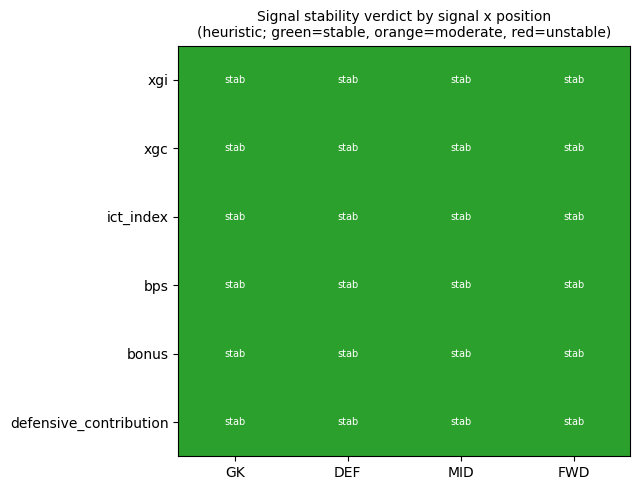

In [7]:
# Verdict grid as a heatmap reveals whether instability clusters by signal or by
# position -- a pattern the long table hides. Encode the 3 verdicts as 0/1/2.
VERDICT_CODE = {"stable": 0, "moderate_shift": 1, "unstable": 2}
grid = (
    signal_stability
    .assign(code=signal_stability["stability_verdict"].map(VERDICT_CODE))
    .pivot(index="signal", columns="position", values="code")
    .reindex(index=SIGNALS, columns=POSITIONS)
)
from matplotlib.colors import ListedColormap, BoundaryNorm
cmap = ListedColormap(["#2ca02c", "#ff7f0e", "#d62728"])  # stable / moderate / unstable
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)
fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(grid.values.astype(float), cmap=cmap, norm=norm, aspect="auto")
ax.set_xticks(range(len(POSITIONS)))
ax.set_xticklabels(POSITIONS)
ax.set_yticks(range(len(grid.index)))
ax.set_yticklabels(grid.index)
label_for = {0: "stab", 1: "mod", 2: "unst"}
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        v = grid.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, label_for[int(v)], ha="center", va="center",
                    color="white", fontsize=7)
ax.set_title("Signal stability verdict by signal x position\n(heuristic; green=stable, orange=moderate, red=unstable)", fontsize=10)
plt.tight_layout()
plt.show()

## What the signals' season-stability looks like

Plain-language summary of the descriptive picture (not a verdict, not a gate):

- **Every studied signal is poolable across the season at every position.** All
  six composite-parent / standalone signals (`xgi`, `xgc`, `ict_index`, `bps`,
  `bonus`, `defensive_contribution`) return `stable` / `pool_confirmed` at all
  four positions over GW1–38 thirds. The median drift that exists is small
  relative to each signal's pooled IQR, so the heuristic does not flip.
- **The p90 ceiling is flat for every signal** — the "good week" upside does not
  escalate across the season at any position. Centre *and* ceiling are stable,
  so pooling is safe in both.
- **The one real tail movement is `defensive_contribution`'s extreme p99,
  rising late** — DEF 17.6→20, MID 17→19, FWD 10.5→12, even though its median
  (6/6/6) and p90 are dead-flat. This is a **tail-only drift the stability
  verdict cannot see** (the verdict is a median-shift heuristic), and it is the
  clearest reason the tail-aware plot exists. Almost certainly the **DGW
  confound**: the DC count doubles in double-gameweeks, which cluster late, so
  the extreme defensive-action tail inflates late without any change in typical
  per-fixture defending.
- **Gentle late upward drift elsewhere is small and centre-level** — `xgi` edges
  up (DEF p90 0.25→0.31, FWD 0.78→0.84) and `xgc`/`ict_index` wobble within
  small-sample noise; all stay inside the `stable` band.
- **`bonus` is bounded [0,3]** — median 0 everywhere and p99 capped at 3, so it
  has no tail to drift; its `stable` verdict reflects a constant-zero median, not
  a characterised distribution. (`bps`, the underlying continuous metric, is
  visible and reads stable with mild noise.)
- **Composite components were dropped, not studied** — `xg`/`xa`,
  `influence`/`creativity`/`threat`, and `tackles`/`clearances_blocks_interceptions`/
  `recoveries` are omitted in favour of their parents (`xgi`, `ict_index`,
  `defensive_contribution`) to avoid double-counting the same information
  (`domain/fpl_signals.py`; see TEMPORAL_DESIGN.md §5).

All figures are **whole-season**, over the **participation** population
(`minutes > 0` — not a performance gate; the 60-minute boundary is deferred to
the `population/` layer). The stability verdict is a heuristic on the **median**,
so by construction it says nothing about the tail — which is why the
distribution plot carries p90/p99 alongside it. Within-player signal dynamics
are deferred to `serial_dependence.ipynb`; per-fixture DGW normalisation is
deferred to the `fixture/` layer.